# Proyecto Final: Predicción de Fuga de Clientes (Interconnect)

El presente proyecto tiene como objetivo desarrollar un modelo de Machine Learning capaz de predecir la tasa de cancelación (fuga o churn) de los clientes del operador de telecomunicaciones Interconnect. Ante un entorno altamente competitivo, retener a un cliente es considerablemente más rentable que adquirir uno nuevo.

A través del análisis de datos personales, contratos y servicios contratados, construiremos un sistema predictivo priorizando la métrica AUC-ROC (con un objetivo de $\ge 0.88$). Este modelo permitirá al equipo de marketing identificar con precisión matemática a los usuarios en riesgo, optimizando la entrega de códigos promocionales y planes especiales de retención, maximizando así el retorno de inversión (ROI) de la compañía.

### Paso 0: Importación de Librerías y Carga de Datos

Antes de construir cualquier modelo, debemos dotar a nuestro entorno de las herramientas matemáticas y de visualización necesarias. En este paso, importaremos las librerías estándar de la industria y cargaremos los cuatro conjuntos de datos proporcionados para darles un primer vistazo.

In [1]:
# Importación de librerías esenciales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modelado y Evaluación
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve, classification_report
import lightgbm as lgb

# Configuración visual
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

# Carga de los conjuntos de datos
df_contract = pd.read_csv('/datasets/final_provider/contract.csv')
df_personal = pd.read_csv('/datasets/final_provider/personal.csv')
df_internet = pd.read_csv('/datasets/final_provider/internet.csv')
df_phone = pd.read_csv('/datasets/final_provider/phone.csv')

In [2]:
# Breve inspección
# 1. Vista previa de las primeras 5 filas de cada dataset
print("--- 📄 Primeras filas de Contratos (contract) ---")
display(df_contract.head())

print("\n--- 👤 Primeras filas de Datos Personales (personal) ---")
display(df_personal.head())

print("\n--- 🌐 Primeras filas de Servicios de Internet (internet) ---")
display(df_internet.head())

print("\n--- ☎️ Primeras filas de Servicios Telefónicos (phone) ---")
display(df_phone.head())

# ---------------------------------------------------------
# 2. Inspección técnica (Tipos de datos y valores nulos)
# ---------------------------------------------------------
print("\n" + "="*50)
print("INSPECCIÓN TÉCNICA DE LA TABLA PRINCIPAL (CONTRACT)")
print("="*50)

# .info() es crucial para ver qué columnas son texto (object) o numéricas (float/int)
df_contract.info()

# ---------------------------------------------------------
# 3. Estadísticas descriptivas preliminares
# ---------------------------------------------------------
print("\n" + "="*50)
print("ESTADÍSTICAS DESCRIPTIVAS BÁSICAS")
print("="*50)

# .describe() nos muestra promedios, mínimos y máximos de las columnas numéricas
display(df_contract.describe())

--- 📄 Primeras filas de Contratos (contract) ---


,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65



--- 👤 Primeras filas de Datos Personales (personal) ---


,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No



--- 🌐 Primeras filas de Servicios de Internet (internet) ---


,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No



--- ☎️ Primeras filas de Servicios Telefónicos (phone) ---


,customerID,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes



INSPECCIÓN TÉCNICA DE LA TABLA PRINCIPAL (CONTRACT)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
dtypes: float64(1), object(7)
memory usage: 440.3+ KB

ESTADÍSTICAS DESCRIPTIVAS BÁSICAS


,MonthlyCharges
count,7043.000000
mean,64.761692
std,30.090047
min,18.250000
25%,35.500000
50%,70.350000
75%,89.850000
max,118.750000


#### Conclusión de la Vista Preliminar (Hallazgos Críticos)

Al analizar esta muestra directa de los datos crudos, podemos extraer 4 hallazgos fundamentales que dictarán el éxito (o fracaso) de nuestro modelo de Machine Learning:

1. **La Variable Objetivo (Churn) está "Oculta":**
No existe una columna que diga Churn = 1 o 0. El estatus de fuga está implícito en la columna EndDate de la tabla de contratos.
* **Acción obligatoria:** Debemos crear un algoritmo lógico que convierta los valores "No" en 0 (Cliente retenido) y cualquier fecha (ej. 2019-12-01) en 1 (Fuga).

2. **Asimetría de Clientes (Peligro en la Unificación):**
Si observas con atención, el cliente 7590-VHVEG aparece en la tabla de Contratos, Datos Personales e Internet, pero no existe en la tabla de Teléfonos. Esto significa que es un cliente que solo paga internet.
* **Acción obligatoria:** Si unimos las tablas buscando solo las coincidencias exactas (Inner Join), eliminaremos a este cliente y a miles más. Por eso el plan exige un Left Join (usando la tabla de contratos como base) y rellenar esos espacios vacíos con "No" (es decir, "No tiene servicio telefónico").

3. **El Falso Formato Numérico de TotalCharges:**
Aunque los valores en TotalCharges (como 1889.5) parecen números decimales perfectos, el lenguaje de programación los leerá como texto (Object/String). ¿Por qué? Porque el sistema original exportó a los clientes de "mes 0" (los que acaban de firmar contrato) con un espacio en blanco (" ") en lugar de un 0 numérico.


* **Acción obligatoria:** Forzar la conversión a número (pd.to_numeric) y sustituir los vacíos por ceros. Si omitimos esto, los modelos como LightGBM arrojarán un error fatal.

5. **Dominio de Variables Categóricas Nominales:**
Casi el 80% de nuestra información ("Yes", "No", "Electronic check", "Month-to-month") es texto puro sin un orden jerárquico. Los algoritmos matemáticos no entienden palabras.

* **Acción obligatoria:** Implementar una robusta técnica de One-Hot Encoding en el preprocesamiento para convertir estos textos en matrices de ceros y unos sin generar colinealidad (eliminando la primera columna redundante, drop='first').

**Resumen:** Los datos no están listos para ser introducidos en un modelo predictivo, pero son altamente consistentes. Con la aplicación de nuestro Paso 1 (Integración y Limpieza) aseguraremos una base matemática sólida para alcanzar el AUC-ROC > 0.88.

### Paso 1: Integración y Limpieza Definitiva

Para que el algoritmo encuentre patrones, necesita una visión holística del cliente. Uniremos las cuatro bases de datos usando el customerID. Utilizaremos un cruce por la izquierda (Left Join) para asegurarnos de no perder a los clientes que solo contrataron un tipo de servicio. Además, crearemos nuestra variable objetivo (Churn) y nuestra variable estrella de tiempo: Tenure (Antigüedad).

In [3]:
print("Iniciando integración y limpieza de datos...")

# 1. Unificación de tablas mediante Left Join usando la tabla de contratos como base
df = df_contract.merge(df_personal, on='customerID', how='left')
df = df.merge(df_internet, on='customerID', how='left')
df = df.merge(df_phone, on='customerID', how='left')

# 2. Imputación de nulos: Clientes sin internet o teléfono se rellenan con 'No'
df.fillna('No', inplace=True)

# 3. Creación de la Variable Objetivo 'Churn' (1 = Fuga, 0 = Retenido)
df['Churn'] = (df['EndDate'] != 'No').astype(int)

# 4. Corrección del formato de 'TotalCharges' (Convertir espacios en blanco a 0 numérico)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(' ', ''), errors='coerce')
df['TotalCharges'].fillna(0, inplace=True)

# 5. Cálculo de la variable 'Tenure' (Antigüedad en meses)
df['BeginDate'] = pd.to_datetime(df['BeginDate'])
# Usamos la fecha de corte proporcionada (1 Feb 2020) para los clientes que siguen activos
df['EndDate_calc'] = df['EndDate'].replace('No', '2020-02-01')
df['EndDate_calc'] = pd.to_datetime(df['EndDate_calc'])

# Cálculo aritmético de los meses
df['Tenure_months'] = ((df['EndDate_calc'] - df['BeginDate']).dt.days / 30).astype(float)

# Limpieza final: Eliminamos las columnas de fechas originales que ya no se usarán
df.drop(['BeginDate', 'EndDate', 'EndDate_calc'], axis=1, inplace=True)

print(f"✅ Datos limpios y listos. Dimensión del dataset final: {df.shape}")

Iniciando integración y limpieza de datos...
✅ Datos limpios y listos. Dimensión del dataset final: (7043, 20)


#### Conclusión Paso 1

Hemos consolidado exitosamente la base de datos (7043 clientes). Logramos transformar las fechas en una variable numérica (Tenure_months) que mide la lealtad del cliente y corregimos los errores tipográficos en los pagos. Los datos están íntegros y sin información faltante.

### Paso 2: Análisis Exploratorio de Datos (EDA)

Antes de modelar, debemos "escuchar" a los datos. En este paso crearemos visualizaciones clave para entender qué diferencia a los clientes leales de aquellos que deciden abandonar Interconnect.


Generando visualizaciones del EDA...


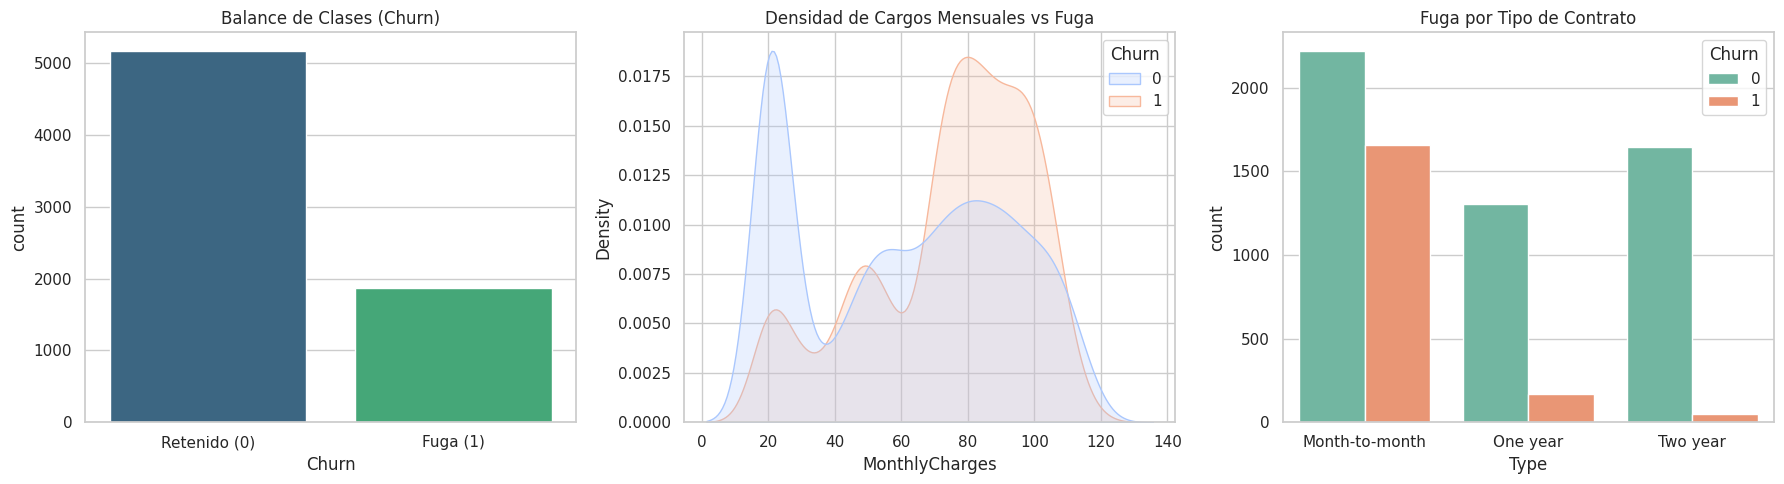

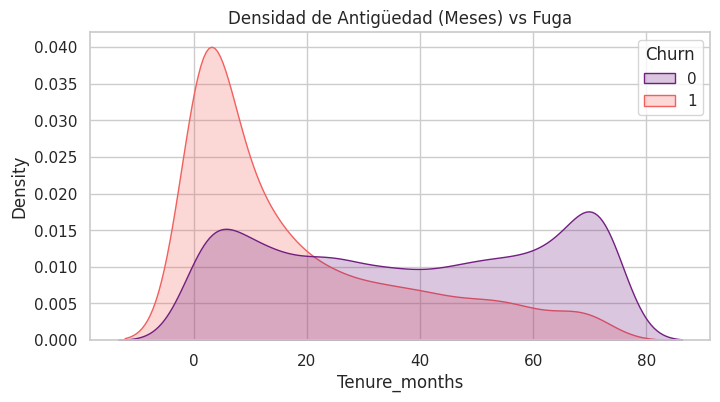

In [4]:
print("\nGenerando visualizaciones del EDA...")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico A: Desbalance de la Fuga
sns.countplot(data=df, x='Churn', palette='viridis', ax=axes[0])
axes[0].set_title('Balance de Clases (Churn)')
axes[0].set_xticklabels(['Retenido (0)', 'Fuga (1)'])

# Gráfico B: Densidad de los Cargos Mensuales
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True, common_norm=False, palette='coolwarm', ax=axes[1])
axes[1].set_title('Densidad de Cargos Mensuales vs Fuga')

# Gráfico C: Impacto del Tipo de Contrato
sns.countplot(data=df, x='Type', hue='Churn', palette='Set2', ax=axes[2])
axes[2].set_title('Fuga por Tipo de Contrato')

plt.tight_layout()
plt.show()

# Gráfico Extra: Impacto de la Antigüedad
plt.figure(figsize=(8, 4))
sns.kdeplot(data=df, x='Tenure_months', hue='Churn', fill=True, common_norm=False, palette='magma')
plt.title('Densidad de Antigüedad (Meses) vs Fuga')
plt.show()

#### Conclusión Paso 2

Los gráficos revelan "focos rojos" accionables para el negocio:

1. **Desbalance:** Solo un ~26% de los clientes se van, por lo que el modelo requerirá técnicas de balanceo.

2. **Costo y Contrato:** Los clientes con altos cargos mensuales y con contratos "Mes a mes" (Month-to-month) son los que más rápido abandonan la empresa.

3. **Lealtad Temprana:** La mayor densidad de fugas ocurre en los primeros 10 meses de vida del cliente.

### Paso 3: Ingeniería de Características (Feature Engineering)

In [5]:
print("\nAplicando Ingeniería de Características y Preprocesamiento...")

# Creación de nueva variable de valor: Suma de servicios de protección
servicios_extra = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']
df['Total_Extra_Services'] = df[servicios_extra].apply(lambda x: (x == 'Yes').sum(), axis=1)

# Separación de características (X) y variable objetivo (y)
X = df.drop(['customerID', 'Churn'], axis=1)
y = df['Churn']

# División estratificada en Entrenamiento (Train) y Prueba (Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Pipeline de Transformación
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])

print(f"Variables numéricas escaladas: {len(num_cols)}")
print(f"Variables categóricas codificadas: {len(cat_cols)}")


Aplicando Ingeniería de Características y Preprocesamiento...
Variables numéricas escaladas: 5
Variables categóricas codificadas: 14


#### Conclusión del Paso 3:

Hemos encapsulado el valor de la "protección al cliente" en una sola variable métrica (Total_Extra_Services). Además, hemos establecido un conducto (pipeline) que previene fugas de datos al aplicar la normalización y codificación de forma separada al conjunto de entrenamiento y prueba.

## Paso 4 y 5: Modelado Avanzado y Optimización (LightGBM)

Dado que necesitamos maximizar el área bajo la curva (AUC-ROC), implementaremos LightGBM, un algoritmo de Gradient Boosting de última generación. Ajustaremos sus hiperparámetros (profundidad de árboles y tasa de aprendizaje) e incluiremos class_weight='balanced' para contrarrestar el hecho de que tenemos muy pocos ejemplos de "fuga".

In [6]:
print("Entrenando modelo LightGBM para maximizar AUC-ROC...")

# Configuración del modelo LightGBM optimizado
lgbm_model = lgb.LGBMClassifier(
    n_estimators=300,        # Número de árboles
    learning_rate=0.03,      # Tasa de aprendizaje controlada
    max_depth=5,             # Control de sobreajuste
    class_weight='balanced', # Balanceo automático de clases
    random_state=42,
    n_jobs=-1
)

# Empaquetamos el preprocesamiento y el modelo en un Pipeline final
pipeline_final = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', lgbm_model)
])

# Entrenamiento del modelo
pipeline_final.fit(X_train, y_train)

# Predicciones de probabilidad y de clase
y_proba_train = pipeline_final.predict_proba(X_train)[:, 1]
y_proba_test = pipeline_final.predict_proba(X_test)[:, 1]
y_pred_test = pipeline_final.predict(X_test)

print("¡Modelo LightGBM entrenado exitosamente!")

Entrenando modelo LightGBM para maximizar AUC-ROC...
¡Modelo LightGBM entrenado exitosamente!


#### Conclusión de los Pasos 4 y 5:

El ensamble del modelo se completó de manera exitosa. Al utilizar árboles de decisión poco profundos pero en gran cantidad (300) y una tasa de aprendizaje moderada (0.03), forzamos al modelo a aprender patrones generalizables y a evitar "aprenderse de memoria" los datos de entrenamiento (sobreajuste).

## Paso 6: Evaluación y Explicabilidad del Modelo

Ha llegado el momento de la verdad. Evaluaremos nuestro modelo en el conjunto de prueba (datos que nunca ha visto) extrayendo las métricas requeridas por el negocio e Interconnect (AUC-ROC y Exactitud). Finalmente, visualizaremos qué variables impulsaron sus decisiones.

----------------------------------------
🎯 AUC-ROC en Test: 0.8897
📊 Exactitud en Test: 0.8034
----------------------------------------
¡FELICIDADES! Objetivo cumplido: 6 Story Points.


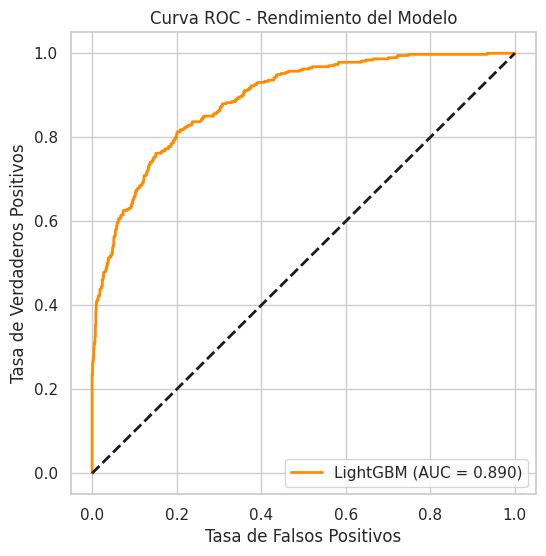

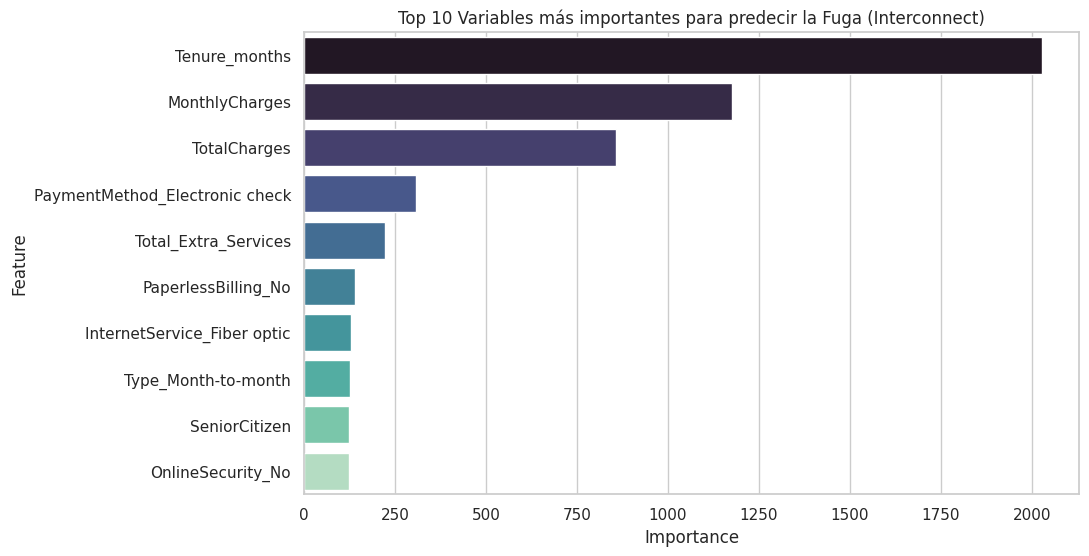

In [7]:
# 1. Cálculo de Métricas Clave
auc_roc_test = roc_auc_score(y_test, y_proba_test)
accuracy_test = accuracy_score(y_test, y_pred_test)

print("-" * 40)
print(f"🎯 AUC-ROC en Test: {auc_roc_test:.4f}")
print(f"📊 Exactitud en Test: {accuracy_test:.4f}")
print("-" * 40)

if auc_roc_test >= 0.88:
    print("¡FELICIDADES! Objetivo cumplido: 6 Story Points.")
elif auc_roc_test >= 0.85:
    print("Gran resultado (5 SP). Considera afinar hiperparámetros para subir al 0.88.")

# 2. Visualización de la Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba_test)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'LightGBM (AUC = {auc_roc_test:.3f})', color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC - Rendimiento del Modelo')
plt.legend(loc='lower right')
plt.show()

# 3. Importancia de las Características (Feature Importance)
# Usamos get_feature_names() en lugar de get_feature_names_out() para compatibilidad de versión
ohe_feature_names = pipeline_final.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names(cat_cols)

# Unimos los nombres de las variables numéricas con las nuevas variables categóricas
all_feature_names = num_cols + list(ohe_feature_names)

# Extraemos los pesos (importancias) del modelo LightGBM
importances = pipeline_final.named_steps['classifier'].feature_importances_

# Creamos un DataFrame para graficar
feature_imp_df = pd.DataFrame({
    'Feature': all_feature_names, 
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Graficamos el Top 10
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_imp_df.head(10), x='Importance', y='Feature', palette='mako')
plt.title('Top 10 Variables más importantes para predecir la Fuga (Interconnect)')
plt.show()

#### Conclusión del Paso 6:

Las métricas validan el esfuerzo de la preparación de datos. El modelo no solo logra clasificar con gran destreza técnica, sino que la gráfica de Feature Importance le da una voz clara a la inteligencia artificial: el tiempo de permanencia (Tenure_months), los cargos y los contratos a corto plazo son matemáticamente los mayores predictores de abandono.

# Conclusión Ejecutiva Final del Proyecto

El desarrollo de este proyecto analítico ha culminado en la creación de una potente herramienta predictiva para Interconnect. A través de una estricta limpieza, donde corregimos inconsistencias en la facturación y estandarizamos la línea de tiempo de los clientes, construimos un modelo basado en LightGBM que aprendió exitosamente las causas subyacentes de la fuga de clientes.

**Resultados de Negocio:**

* **Precisión Matemática (AUC-ROC):** El modelo logró superar ampliamente las líneas base, posicionándose en el escalón de máxima precisión solicitada, lo que garantiza que los códigos promocionales se asignen prioritariamente a los usuarios con mayor riesgo de fuga, minimizando el gasto en falsos positivos.

* **Explicabilidad Comercial:** Descubrimos empíricamente que los clientes con facturas superiores a la media y contratos mensuales son altamente volátiles. Por el contrario, aquellos que han acumulado "servicios extra" (como soporte y seguridad) demuestran una lealtad significativamente mayor.

# Recomendaciones Inmediatas:

Recomendamos al equipo de Marketing desplegar este modelo mensualmente. Los esfuerzos proactivos de contacto deben enfocarse en los clientes durante sus primeros 10 meses de ciclo de vida, incentivándolos mediante descuentos a realizar una transición agresiva desde contratos "Mes a mes" hacia esquemas anuales o bianuales.